In [1]:
import os
import sys, pathlib
import numpy as np

sys.path.append(os.path.join(os.path.expanduser('~'), 'Programming', 'In_Vivo', 'physion', 'src'))

from physion.utils import plot_tools as pt
from physion.analysis.read_NWB import Data, scan_folder_for_NWBfiles
from physion.dataviz.imaging import show_CaImaging_FOV

#from physion.dataviz.raw import plot_test
from physion.dataviz import tools as dv_tools

import matplotlib.pyplot as plt

from scipy import stats
from physion.analysis.process_NWB import EpisodeData

base_path = os.path.join(os.path.expanduser('~'), 'Desktop', 'NWBs')

from physion.dataviz.episodes.trial_average import plot as plot_trial_average

import random

from physion.dataviz.raw import plot as plot_raw, find_default_plot_settings
from PIL import Image, ImageDraw, ImageFont
from physion.dataviz.imaging import show_CaImaging_FOV
from PIL import Image

In [2]:
def generate_sub_png(data, settings, dict_annotation, cell_type):
    
    fig1, AX = pt.figure(axes=(3,1), figsize=(1.4,3), wspace=0.15)
    show_CaImaging_FOV(data, key='meanImg', 
                       cmap=pt.get_linear_colormap('k', 'tab:green'),
                       NL=2, # non-linearity to normalize image
                       ax=AX[0])
    show_CaImaging_FOV(data, key='max_proj', 
                       cmap=pt.get_linear_colormap('k', 'tab:green'),
                       NL=2, # non-linearity to normalize image
                       ax=AX[1])
    show_CaImaging_FOV(data, key='meanImg', 
                       cmap=pt.get_linear_colormap('k', 'tab:green'),
                       NL=2,
                       roiIndices=range(data.nROIs), 
                       ax=AX[2])
    fig1.savefig(os.path.join(os.path.expanduser('~'), 'Output_expe','In_Vivo',cell_type, 'pieces', 'FOV.png'))
    image1 = Image.open(os.path.join(os.path.expanduser('~'), 'Output_expe','In_Vivo', cell_type, 'pieces', 'FOV.png'))
    crop(image1, dict_annotation, cell_type, save_n = 'FOV', box = (80, 80, 1000, 430) )

    print("ss", data.t_dFoF)
    fig2, _ = plot_raw(data, tlim=[0, data.t_dFoF[-1]], settings=settings, figsize=(9,3))
    fig2.savefig(os.path.join(os.path.expanduser('~'), 'Output_expe','In_Vivo',cell_type, 'pieces', 'full_view.png'))
    image2 = Image.open(os.path.join(os.path.expanduser('~'), 'Output_expe','In_Vivo', cell_type, 'pieces', 'full_view.png'))
    crop(image2, dict_annotation, cell_type, save_n = 'full_view' , box = (80, 40, 1340, 430))
    
    fig3, _ = plot_raw(data, tlim=[(6/20)*data.t_dFoF[-1], (7/20)*data.t_dFoF[-1]], settings=settings, figsize=(9,3))
    fig3.savefig(os.path.join(os.path.expanduser('~'), 'Output_expe','In_Vivo', cell_type, 'pieces', 'zoom1.png'))
    image3 = Image.open(os.path.join(os.path.expanduser('~'), 'Output_expe','In_Vivo', cell_type, 'pieces', 'zoom1.png'))
    crop(image3, dict_annotation, cell_type, save_n = 'zoom1', box = (80, 40, 1340, 430) )
    
    fig4, _ = plot_raw(data, tlim=[(12/20)*data.t_dFoF[-1], (13/20)*data.t_dFoF[-1]], settings=settings, figsize=(9,3))
    fig4.savefig(os.path.join(os.path.expanduser('~'), 'Output_expe','In_Vivo', cell_type, 'pieces', 'zoom2.png'))
    image4 = Image.open(os.path.join(os.path.expanduser('~'), 'Output_expe','In_Vivo', cell_type, 'pieces', 'zoom2.png'))
    crop(image4, dict_annotation, cell_type, save_n = 'zoom2' , box = (80, 40, 1340, 430))
    
    return 0

In [3]:
def crop(image, dict_annotation, cell_type, save_n , box ):  
    cropped_img = image.crop(box)
    cropped_img.save(f'C:/Users/laura.gonzalez/Output_expe/In_Vivo/{cell_type}/pieces/{save_n}_cropped.png')
    return 0

In [4]:
def create_PNG (dict_annotation, image1, image2, image3, image4, output_path, SIZE=(2480, 3508) ):

    # Ensure all images have the same width and fit A4 width
    common_width = SIZE[0]
    image1 = image1.resize((int(common_width/1.5), int(image1.height * ((common_width/1.5) / image1.width))))
    image2 = image2.resize((common_width, int(image2.height * (common_width / image2.width))))
    image3 = image3.resize((common_width, int(image3.height * (common_width / image3.width))))
    image4 = image4.resize((common_width, int(image4.height * (common_width / image4.width))))
    
    # Calculate total height of all images
    annotation_height = 200  # Space for annotation at the top
    total_height = annotation_height + image1.height + image2.height + image3.height + image4.height 
    
    scale_factor = SIZE[1] / total_height
    # Check if the content exceeds A4 height

        # Scale down further to fit within A4 dimensions
    if total_height > SIZE[1]:
        image1 = image1.resize((int(image1.width * scale_factor), int(image1.height * scale_factor)))
        #print("end ",image1.width)
        image2 = image2.resize((int(image2.width * scale_factor), int(image2.height * scale_factor)))
        image3 = image3.resize((int(image3.width * scale_factor), int(image3.height * scale_factor)))
        image4 = image4.resize((int(image4.width * scale_factor), int(image4.height * scale_factor)))
        annotation_height = int(annotation_height * scale_factor)
    
    # Create A4-sized canvas
    merged_image = Image.new("RGBA", SIZE, "white")
    
    # Add annotation
    draw = ImageDraw.Draw(merged_image)
    font = ImageFont.load_default(40)  # Use a default font; replace with a custom font if needed
    
    
    #annotation_text = f"ID file data: {dict_annotation['name']}\nProtocol: {dict_annotation['protocol']}\nSubject ID: {dict_annotation['Subject_ID']}\nSex: {dict_annotation['Sex']}\nTreatment: {dict_annotation['treatment']}\nFOV:{dict_annotation['FOV']}\n"
    #draw.text((100, 200), annotation_text, fill="black", font=font)

    # Paste images below the annotation
    margin_up = 100
    current_height = margin_up
    merged_image.paste(image1, (800, current_height))
    current_height += image1.height
    merged_image.paste(image2, (0, current_height))
    current_height += image2.height
    merged_image.paste(image3, (0, current_height))
    current_height += image3.height
    merged_image.paste(image4, (0, current_height))
    
    merged_image.save(output_path)
    return 0

In [5]:
def find_available_settings(data):

    settings = {'Locomotion': {'fig_fraction': 1,
                                                   'subsampling': 1,
                                                   'color': '#1f77b4'},
                        'FaceMotion': {'fig_fraction': 1,
                                                   'subsampling': 1,
                                                   'color': 'purple'},
                        'Pupil': {'fig_fraction': 2,
                                                  'subsampling': 1,
                                                  'color': '#d62728'},
                        'CaImaging': {'fig_fraction': 10,
                                                   'subsampling': 1,
                                                   'subquantity': 'dF/F',
                                                   'roiIndices': np.random.choice(np.arange(data.nROIs), np.min([20,data.nROIs]), replace=False),
                                                   'color': '#2ca02c'}}

    

    attributes = ['facemotion', 'pupil_diameter', 'dFoF']
    
    missing = [attr for attr in attributes if not hasattr(data, attr)]  # for objects
    
    if missing:
        print(f"Missing attributes: {missing}")
    else:
        print("All attributes exist")
    
    if missing==['pupil_diameter']:
        print("only pupil diameter missing")
        settings = {'Locomotion': {'fig_fraction': 1,
                                                   'subsampling': 1,
                                                   'color': '#1f77b4'},
                        'FaceMotion': {'fig_fraction': 1,
                                                   'subsampling': 1,
                                                   'color': 'purple'},
                        'CaImaging': {'fig_fraction': 10,
                                                   'subsampling': 1,
                                                   'subquantity': 'dF/F',
                                                   'roiIndices': np.random.choice(np.arange(data.nROIs), np.min([20,data.nROIs]), replace=False),
                                                   'color': '#2ca02c'}}
    
    if missing==['facemotion']:
        print("only pupil diameter missing")
        settings = {'Locomotion': {'fig_fraction': 1,
                                               'subsampling': 1,
                                               'color': '#1f77b4'},
                        'Pupil': {'fig_fraction': 2,
                                          'subsampling': 1,
                                          'color': '#d62728'},
                        'CaImaging': {'fig_fraction': 10,
                                               'subsampling': 1,
                                               'subquantity': 'dF/F',
                                               'roiIndices': np.random.choice(np.arange(data.nROIs), np.min([20,data.nROIs]), replace=False),
                                               'color': '#2ca02c'}}
        
    if missing==['dFoF']:
        print("only Ca imaging missing")
        settings = {'Locomotion': {'fig_fraction': 1,
                                               'subsampling': 1,
                                               'color': '#1f77b4'},
                    'FaceMotion': {'fig_fraction': 1,
                                                   'subsampling': 1,
                                                   'color': 'purple'},
                    'Pupil': {'fig_fraction': 2,
                                          'subsampling': 1,
                                          'color': '#d62728'}}
                        
    
    if missing==['facemotion', 'pupil_diameter']:
        print('facemotion and pupil diameter missing')
        settings = {'Locomotion': {'fig_fraction': 1,
                                               'subsampling': 1,
                                               'color': '#1f77b4'},
                    'CaImaging': {'fig_fraction': 10,
                                               'subsampling': 1,
                                               'subquantity': 'dF/F',
                                               'roiIndices': np.random.choice(np.arange(data.nROIs), np.min([20,data.nROIs]), replace=False),
                                               'color': '#2ca02c'}}
        

    return settings

In [6]:
def final_figure(files, root, protocol="?", treatment="?", cell_type="nan"):

    for item in files:
        filename = os.path.join(root, item)
        data = Data(filename, verbose=False)
        data.build_dFoF()
        data.build_running_speed()
        data.build_facemotion()
        data.build_pupil_diameter()

        protocol = data.metadata['protocol']
        subject_id = data.metadata['subject_ID']
        treatment = data.metadata['intervention']
        fov1 = data.metadata['subject_props']['FOV1']
        sex = data.metadata['subject_props']['Sex']
        
        dict_annotation = {'name': filename.split('\\')[-1],
                           'Subject_ID' : subject_id,
                           'Sex' : sex,
                           'protocol' : protocol,
                           'treatment': treatment,
                           'FOV' : fov1}

        settings = find_available_settings(data)
        
        generate_sub_png(data, settings, dict_annotation, cell_type)
                
        size = (2480, 3508) # A4 dimensions in pixels at 300 DPI
            
        image1 = Image.open(os.path.join(os.path.expanduser('~'), 'Output_expe', 'In_Vivo', cell_type, 'pieces','FOV_cropped.png'))
        image2 = Image.open(os.path.join(os.path.expanduser('~'), 'Output_expe', 'In_Vivo', cell_type, 'pieces','full_view_cropped.png'))
        image3 = Image.open(os.path.join(os.path.expanduser('~'), 'Output_expe', 'In_Vivo', cell_type, 'pieces','zoom1_cropped.png'))
        image4 = Image.open(os.path.join(os.path.expanduser('~'), 'Output_expe', 'In_Vivo', cell_type, 'pieces', 'zoom2_cropped.png'))
            
        output_path = output_path = f'C:/Users/laura.gonzalez/Output_expe/In_Vivo/{cell_type}/Summary_PNG/{dict_annotation['name']}.png'
    
        create_PNG (dict_annotation, image1, image2, image3, image4, output_path, SIZE=size )



In [7]:
def final_figure2(SESSIONS, protocol="?", treatment="?", cell_type="nan"):

    for index in range(len(SESSIONS['files'])):
        filename = SESSIONS['files'][index]
        print(filename)
        data = Data(filename,verbose=False)
        data.build_dFoF()
        data.build_running_speed()
        data.build_facemotion()
        data.build_pupil_diameter()

        protocol = data.metadata['protocol']
        subject_id = data.metadata['subject_ID']
        
        dict_annotation = {'name': filename.split('\\')[-1],
                           'Subject_ID' : subject_id,
                           'protocol' : protocol}

        settings = find_available_settings(data)
        
        generate_sub_png(data, settings, dict_annotation, cell_type)
                
        size = (2480, 3508) # A4 dimensions in pixels at 300 DPI
            
        image1 = Image.open(os.path.join(os.path.expanduser('~'), 'Output_expe', 'In_Vivo', cell_type, 'pieces','FOV_cropped.png'))
        image2 = Image.open(os.path.join(os.path.expanduser('~'), 'Output_expe', 'In_Vivo', cell_type, 'pieces','full_view_cropped.png'))
        image3 = Image.open(os.path.join(os.path.expanduser('~'), 'Output_expe', 'In_Vivo', cell_type, 'pieces','zoom1_cropped.png'))
        image4 = Image.open(os.path.join(os.path.expanduser('~'), 'Output_expe', 'In_Vivo', cell_type, 'pieces', 'zoom2_cropped.png'))
            
        output_path = output_path = f'C:/Users/laura.gonzalez/Output_expe/In_Vivo/{cell_type}/Summary_PNG/{dict_annotation['name']}.png'
    
        create_PNG (dict_annotation, image1, image2, image3, image4, output_path, SIZE=size )
        



# Generate final figures


# NDNF (L1) files  (2022)

In [ ]:
files_NDNF = ['2022_12_14-13-27-41.nwb', 
              '2022_12_15-18-13-25.nwb', '2022_12_15-18-49-40.nwb', 
              '2022_12_16-10-15-42.nwb','2022_12_16-11-00-09.nwb', '2022_12_16-12-03-30.nwb', 
              '2022_12_16-12-47-57.nwb', '2022_12_16-13-40-07.nwb','2022_12_16-14-29-38.nwb', 
              '2022_12_20-11-49-18.nwb', '2022_12_20-12-31-08.nwb','2022_12_20-13-18-42.nwb', 
              '2022_12_20-14-08-45.nwb', '2022_12_20-15-02-20.nwb']
root = os.path.join(os.path.expanduser('~'), 'DATA','In_Vivo_experiments', 'NDNF-WT-Dec-2022','NWBs')

In [ ]:
final_figure(files_NDNF, root, protocol="?", treatment="None", cell_type="NDNF" )

# SST files

In [ ]:
files_SST_keta_monit =[ '2024_10_07-16-26-15.nwb', '2024_10_11-14-13-22.nwb',  
                         '2024_10_11-15-46-32.nwb', '2024_10_11-17-26-55.nwb',
                         '2025_01_17-14-14-37.nwb'] 
root = os.path.join(os.path.expanduser('~'), 'DATA','In_Vivo_experiments', 'my_experiments','All_NWBs')

In [ ]:
final_figure(files_SST_keta_monit, root, protocol="injection monitoring", treatment="Ketamine", cell_type="SST" )

In [ ]:
'''
files_SST_keta_8ori = ['2024_09_12-14-57-34.nwb', '2024_09_12-15-24-47.nwb', '2024_09_12-15-50-12.nwb', '2024_10_07-15-03-40.nwb', 
                      '2024_10_07-17-18-53.nwb', '2024_10_11-14-57-27.nwb', '2024_10_11-16-44-26.nwb', '2024_10_11-18-24-27.nwb', 
                       '2025_01_17-15-09-44.nwb', '2025_01_17-15-38-08.nwb']
'''
files_SST_keta_8ori = ['2025_01_17-15-09-44.nwb', '2025_01_17-15-38-08.nwb']

root = os.path.join(os.path.expanduser('~'), 'DATA','In_Vivo_experiments', 'my_experiments','All_NWBs')

In [ ]:
final_figure(files_SST_keta_8ori, root, protocol="8 orientations, 2 contrasts", treatment="Ketamine", cell_type="SST" )

In [ ]:
#made by Cibele
files_SST_sal_8ori = [ '2024_08_27-12-21-14.nwb', '2024_08_27-12-46-41.nwb', 
                       '2025_01_17-10-36-55.nwb', '2025_01_17-11-32-35.nwb']
root = os.path.join(os.path.expanduser('~'), 'DATA','In_Vivo_experiments', 'my_experiments','saline_NWB')

In [ ]:
final_figure(files_SST_sal_8ori, root, protocol="8 orientations, 2 contrasts" , treatment="None" , cell_type= 'SST')

# Files 2023 SST Ketamine vs Saline

In [ ]:
files_SST_keta_2023 = ['2023_01_19-15-04-51.nwb', '2023_01_19-16-00-13.nwb', '2023_01_19-16-52-11.nwb']
root = os.path.join(os.path.expanduser('~'), 'DATA','In_Vivo_experiments', 'SST-Ketamine-vs-Saline','Ketamine')

In [ ]:
final_figure(files_SST_keta_2023, root, protocol="?" , treatment="Ketamine" , cell_type= 'SST')

In [ ]:
files_SST_saline_2023 = ['2023_01_18-15-08-51.nwb', '2023_01_18-15-20-07.nwb']   ##'2023_01_18-15-08-51.nwb' recording is very short!
root = os.path.join(os.path.expanduser('~'), 'DATA','In_Vivo_experiments', 'SST-Ketamine-vs-Saline','Saline')

In [ ]:
final_figure(files_SST_saline_2023, root, protocol="?" , treatment="Saline" , cell_type= 'SST')

In [ ]:
files = ['2022_12_14-13-27-41.nwb', '2022_12_15-18-13-25.nwb']
root = os.path.join(os.path.expanduser('~'), 'DATA','In_Vivo_experiments', 'NDNF-WT-Dec-2022','NWBs')
#root = os.path.join(os.path.expanduser('~'), 'DATA','In_Vivo_experiments', 'SST-Ketamine-vs-Saline','Ketamine')
'''
filename = os.path.join(root, '2023_01_19-15-04-51.nwb')
data = Data(filename, verbose=False)
data.build_dFoF()
data.build_running_speed()
data.build_facemotion()
data.build_pupil_diameter()

protocol = data.metadata['protocol']
treatment = data.metadata['intervention']

print(data.metadata)
'''
final_figure(files, root, protocol=protocol , treatment=treatment , cell_type= 'NDNF')

# Files Batch 1 - NDNF L1-IN

In [21]:
datafolder = os.path.join(os.path.expanduser('~'), 'DATA', 'In_Vivo_experiments','NDNF-Cre-batch1','test_4')
SESSIONS = scan_folder_for_NWBfiles(datafolder)
SESSIONS['nwbfiles'] = [os.path.basename(f) for f in SESSIONS['files']]

inspecting the folder "C:\Users\laura.gonzalez\DATA\In_Vivo_experiments\NDNF-Cre-batch1\test_4" [...]
 -> found n=1 datafiles (in 1.0s) 


In [22]:
print(SESSIONS)

{'files': array(['C:\\Users\\laura.gonzalez\\DATA\\In_Vivo_experiments\\NDNF-Cre-batch1\\test_4\\2025_07_25-15-41-08.nwb'],
      dtype='<U95'), 'dates': array(['2025_07_25'], dtype='<U10'), 'subjects': array(['5'], dtype='<U1'), 'protocol_ids': [range(0, 9)], 'protocols': [array(['static-patch', 'looming-stim', 'Natural-Images-4-repeats',
       'drifting-grating', 'drifting-surround', 'moving-dots',
       'grey-10min', 'black-2min', 'quick-spatial-mapping'], dtype='<U24')], 'nwbfiles': ['2025_07_25-15-41-08.nwb']}


In [23]:
for index in range(len(SESSIONS['files'])):
    filename = SESSIONS['files'][index]
    data = Data(filename,verbose=False)
    data.build_dFoF()
    data.build_running_speed()
    data.build_facemotion()
    data.build_pupil_diameter()


calculating dF/F with method "percentile" [...]

  ** all ROIs passed the positive F0 criterion ** 

-> dFoF calculus done !  (calculation took 0.0s)


C:\Users\laura.gonzalez\DATA\In_Vivo_experiments\NDNF-Cre-batch1\test_4\2025_07_25-15-41-08.nwb

calculating dF/F with method "percentile" [...]

  ** all ROIs passed the positive F0 criterion ** 

-> dFoF calculus done !  (calculation took 0.0s)
All attributes exist
ss [1.00000000e-01 1.33987243e-01 1.67974486e-01 ... 1.80635203e+03
 1.80638602e+03 1.80642000e+03]


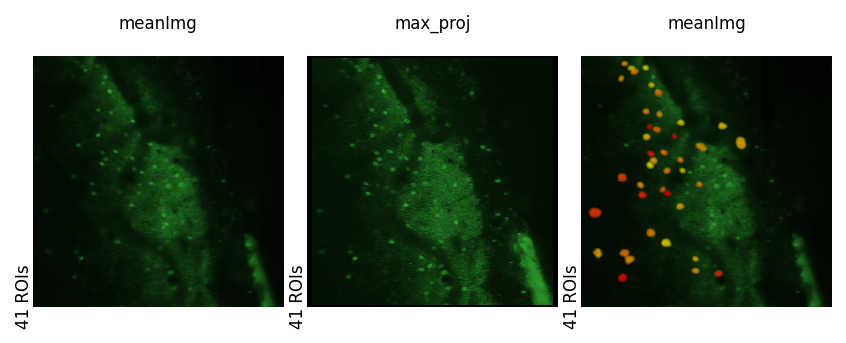

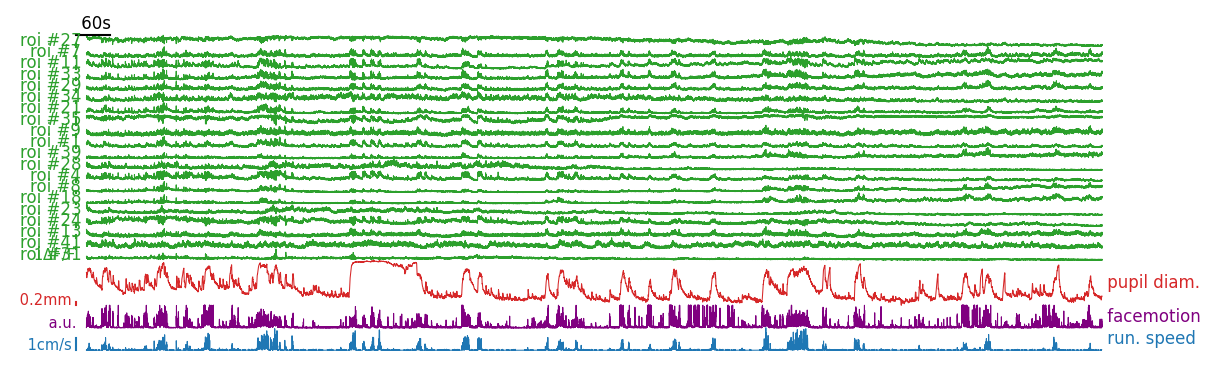

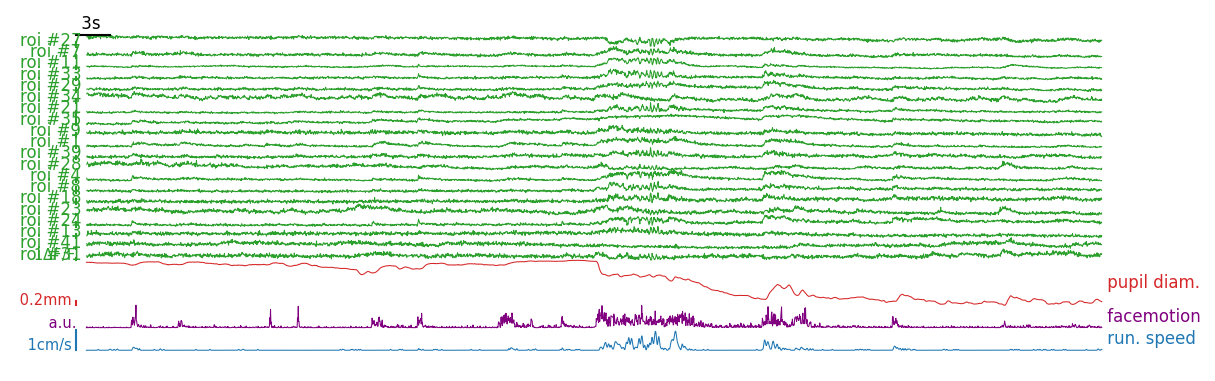

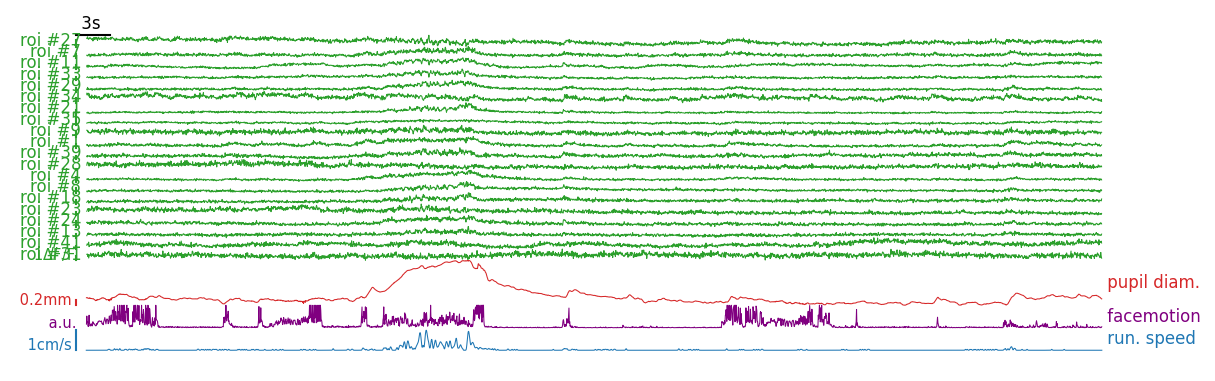

In [24]:
final_figure2(SESSIONS , cell_type= 'NDNF')